In [4]:
import pandas as pd
data =pd.read_csv(r'C:\Users\pc\Downloads\Iris.csv')
print(data.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [5]:
data.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
data.isna().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
print(data.dtypes)

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object


In [10]:
print(data['Species'].unique())

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [11]:
print(data.describe())

               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000


In [12]:
print(data['Species'].value_counts())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [13]:
corr = data.drop(columns='Species').corr()
print(corr)
heatmap(corr, annot=True)
plt.show()

                     Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  \
Id             1.000000       0.716676     -0.397729       0.882747   
SepalLengthCm  0.716676       1.000000     -0.109369       0.871754   
SepalWidthCm  -0.397729      -0.109369      1.000000      -0.420516   
PetalLengthCm  0.882747       0.871754     -0.420516       1.000000   
PetalWidthCm   0.899759       0.817954     -0.356544       0.962757   

               PetalWidthCm  
Id                 0.899759  
SepalLengthCm      0.817954  
SepalWidthCm      -0.356544  
PetalLengthCm      0.962757  
PetalWidthCm       1.000000  


NameError: name 'heatmap' is not defined

In [14]:
print(data.groupby('Species').mean())

                    Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  \
Species                                                              
Iris-setosa       25.5          5.006         3.418          1.464   
Iris-versicolor   75.5          5.936         2.770          4.260   
Iris-virginica   125.5          6.588         2.974          5.552   

                 PetalWidthCm  
Species                        
Iris-setosa             0.244  
Iris-versicolor         1.326  
Iris-virginica          2.026  


In [15]:
for col in data.columns:
    if col != 'Species':
        print(col, 'min', data[col].min(), 'max', data[col].max())

Id min 1 max 150
SepalLengthCm min 4.3 max 7.9
SepalWidthCm min 2.0 max 4.4
PetalLengthCm min 1.0 max 6.9
PetalWidthCm min 0.1 max 2.5


In [16]:
import pandas as pd 
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [17]:
iris = load_iris(as_frame=True)
data = iris.frame

In [18]:
data.rename(columns={'target': 'Species'}, inplace=True)

In [19]:
data['Species'] = data['Species'].apply(lambda x: iris.target_names[x])

In [20]:
X = data.drop(columns='Species')
y = data['Species']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [22]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [23]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score

log_acc = accuracy_score(y_test, y_pred_log)
tree_acc = accuracy_score(y_test, y_pred_tree)

print('Logistic Regression Accuracy:', log_acc)
print('Decision Tree Accuracy:', tree_acc)

Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0


In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

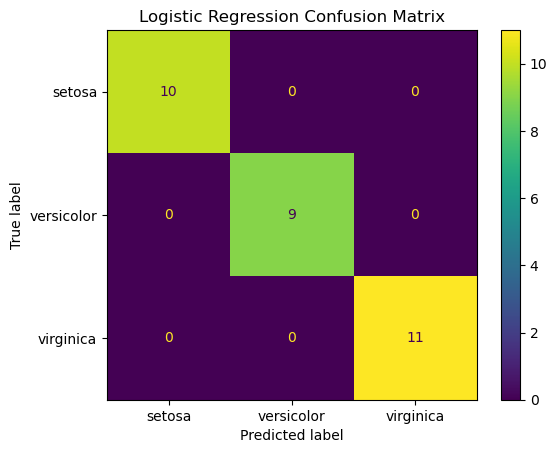

In [27]:
cm_log = confusion_matrix(y_test, y_pred_log)

disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log,
                                  display_labels=log_model.classes_)
disp_log.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [31]:
print("\n=== Predict New Iris Flower ===")


=== Predict New Iris Flower ===


In [35]:
try:
    sepal_length = float(input('Enter sepal length (cm):'))
    sepal_width = float(input('Enter sepal width (cm):'))
    petal_length = float(input('Enter petal lenght(cm):'))
    petal_width = float(input('Enter petal width (cm):'))
    user_data = pd.DataFrame([[sepal_length, sepal_width, petal_length, petal_width]],
                       columns=X.columns)
    prediction = log_model.predict(user_data)
    print("\n🌸 Predicted species:", prediction[0])
except ValueError:
    print("❌ Please enter valid numeric values.")
    

Enter sepal length (cm): 6
Enter sepal width (cm): 3
Enter petal lenght(cm): 4.8
Enter petal width (cm): 1.8



🌸 Predicted species: virginica
